In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin


In [33]:
data = pd.read_csv('../M1_final.csv')
data.head()

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,TAIL_NUM,DEST,DEP_DELAY,CRS_ELAPSED_TIME,DISTANCE,CRS_DEP_M,...,Dew Point,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Condition,sch_dep,sch_arr,TAXI_OUT
0,11,1,5,B6,N828JB,CHS,-1,124,636,324,...,34,58,W,25,38,29.86,Fair / Windy,9,17,14
1,11,1,5,B6,N992JB,LAX,-7,371,2475,340,...,34,58,W,25,38,29.86,Fair / Windy,9,17,15
2,11,1,5,B6,N959JB,FLL,40,181,1069,301,...,34,58,W,25,38,29.86,Fair / Windy,9,17,22
3,11,1,5,B6,N999JQ,MCO,-2,168,944,345,...,34,58,W,25,38,29.86,Fair / Windy,9,17,12
4,11,1,5,DL,N880DN,ATL,-4,139,760,360,...,32,58,W,24,35,29.91,Fair / Windy,9,17,13


In [34]:
# Drop unnecessary features
data.drop(columns=['TAIL_NUM', 'DEP_TIME_M', 'TAXI_OUT'], inplace=True)

# create target variable
data['is_delayed'] = np.where(
    data['DEP_DELAY'] >= 15,
    1,
    0
)
data.drop(columns=['DEP_DELAY'], inplace=True)

# Drop null rows
data.dropna(inplace=True)

## Feature engineering

In [35]:
def get_time_of_day(minutes):
    if 300 <= minutes < 720:        # 5:00am - 11:59am
        return 'Morning'
    elif 720 <= minutes < 1020:     # 12:00pm - 4:59pm
        return 'Afternoon'
    elif 1020 <= minutes < 1260:    # 5:00pm - 8:59pm
        return 'Evening'
    else:                           # 9:00pm - 4:59am
        return 'Night'
    

data['time_of_day'] = data['CRS_DEP_M'].apply(get_time_of_day)


In [ ]:
# Function to create temporal features without data leakage
def create_temporal_features(df):
    
    df = df.copy()
    
    # Sort by destination and departure time
    df = df.sort_values(["DEST", "CRS_DEP_M"])
    
    # Previous flight delay at same destination
    df["prev_delay"] = df.groupby("DEST")["is_delayed"].shift(1)
    
    # Rolling delay rate over last 3 flights at same destination
    df["rolling_delay_rate_3"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Rolling delay rate over last 5 flights at same destination
    df["rolling_delay_rate_5"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(5, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Fill NaN values from the shift operation
    df["prev_delay"] = df["prev_delay"].fillna(0)
    
    return df

## Train test split

In [38]:
# Stratified Train test split
from sklearn.model_selection import StratifiedShuffleSplit

x = data.drop('is_delayed', axis=1)
y = data['is_delayed']

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

for train_index, test_index in splitter.split(data, data['is_delayed']):
    # Split the data first
    train_data = data.iloc[train_index].copy()
    test_data = data.iloc[test_index].copy()
    
    # Apply temporal features separately to avoid leakage
    train_data = create_temporal_features(train_data)
    test_data = create_temporal_features(test_data)
    
    # Now split into X and y
    x_train = train_data.drop('is_delayed', axis=1)
    y_train = train_data['is_delayed']
    x_test = test_data.drop('is_delayed', axis=1)
    y_test = test_data['is_delayed']

## Wind direction transformer

In [39]:
class WindDirectionTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Wind'):
        self.column = column
        self.wind_dict = {
            'NNW': 340, 'CALM': 0, 'NNE': 20, 'NE': 45, 'VAR': 0, 'WSW': 230, 
            'S': 180, 'SSW': 200, 'WNW': 290, 'ESE': 115, 'N': 360, 'SW': 225, 
            'E': 90, 'W': 270, 'SSE': 155, 'ENE': 70, 'NW': 315, 'SE': 135
        }

    def fit(self, X, y=None):
        return self
    

    def transform(self, X):
        X = X.copy()
        # Map wind directions to degrees
        X['wind_deg'] = X[self.column].map(self.wind_dict)
        # Convert to radians
        X['wind_rad'] = np.deg2rad(X['wind_deg'])
        #Compute sin and cos
        X['wind_sin'] = np.sin(X['wind_rad'])
        X['wind_cos'] = np.cos(X['wind_rad'])
        # Drop original columns
        X = X.drop(columns=[self.column, 'wind_deg', 'wind_rad'])
        return X

## Dew point transformer

In [40]:
class DewPointTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Dew Point'):
        self.column = column
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()

        # Clean column
        X[self.column] = (
            X[self.column].astype(str).str.replace('\xa0', '', regex=False).str.strip()
        )
        # Convert them into numeric values
        X[self.column] = pd.to_numeric(X[self.column], errors='coerce')

        return X

In [41]:
# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('Wind transformer', WindDirectionTransformer(column='Wind'), ['Wind']),
    ('Dew Point Transformer', DewPointTransformer(column='Dew Point'), ['Dew Point']),
    ('OrdinalEncoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['DEST', 'OP_UNIQUE_CARRIER', 'Condition']),
    ('OneHotEncoder', OneHotEncoder(handle_unknown='ignore', drop='first'), ['time_of_day'])
], remainder='passthrough')

In [42]:
from xgboost import XGBClassifier

xgboost_model = XGBClassifier(
    max_depth=7,
    n_estimators=462,
    learning_rate= 0.07468889167695233,
    subsample=0.8433133977413599,
    colsample_bytree=0.8651581198356619,
    min_child_weight=4,
    gamma=0.221274461259664,
    reg_alpha=0.4371325502940443,
    reg_lambda=0.4162692001156498,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    
)

In [43]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('Preprocessor', preprocessor),
    ('Train XGBoost', xgboost_model)
])

In [44]:
pipe.fit(x_train, y_train)

/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:09:33] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,steps,"[('Preprocessor', ...), ('Train XGBoost', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Wind transformer', ...), ('Dew Point Transformer', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [45]:
y_pred = pipe.predict(x_test)

In [46]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)*100

94.0087901919963

In [47]:
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score

In [48]:
cross_val_score(pipe, x_train, y_train, cv=5, scoring='accuracy').mean() * 100

/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:14:20] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:14:22] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:14:22] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/faraaz/code/minorProject/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:14:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


np.float64(92.08817738196826)

In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      7440
           1       0.80      0.77      0.78      1206

    accuracy                           0.94      8646
   macro avg       0.88      0.87      0.87      8646
weighted avg       0.94      0.94      0.94      8646



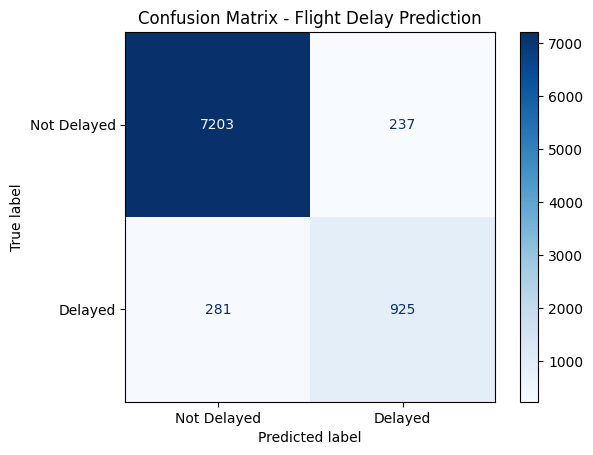

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix with labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Delayed', 'Delayed'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Flight Delay Prediction')
plt.show()

ROC AUC Score: 98.0503


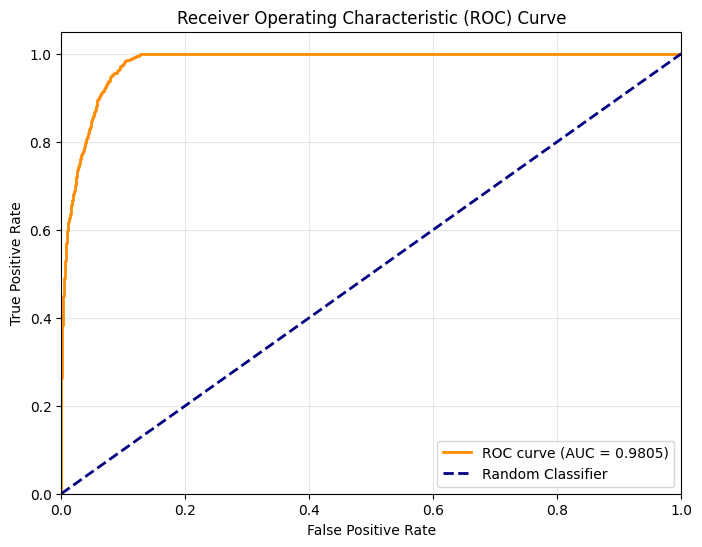

In [55]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get prediction probabilities for ROC curve
y_pred_proba = pipe.predict_proba(x_test)[:, 1]

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC AUC Score: {100 * roc_auc:.4f}')

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [57]:
# Calculate Specificity (True Negative Rate)
# Specificity = TN / (TN + FP)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)  # Also known as Recall or True Positive Rate

print(f'Specificity (True Negative Rate): {specificity:.4f} or {100 * specificity:.2f}%')
print(f'Sensitivity (True Positive Rate): {sensitivity:.4f} or {100 * sensitivity:.2f}%')

Specificity (True Negative Rate): 0.9681 or 96.81%
Sensitivity (True Positive Rate): 0.7670 or 76.70%
